In [25]:
# ============================================================
# CELL 1 : IMPORT + DATASET + PREPROCESSING + DATALOADER
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

dataset_path = "/content/Dataset_BUSI_with_GT"

image_paths = []
labels = []

for cls in ["benign","normal","malignant"]:

    folder = os.path.join(dataset_path,cls)

    for file in os.listdir(folder):

        if "_mask" in file:
            continue

        image_paths.append(os.path.join(folder,file))

        if cls=="malignant":
            labels.append(1)
        else:
            labels.append(0)

print("Total Images :",len(image_paths))
print("Cancer :",sum(labels))
print("Non Cancer :",len(labels)-sum(labels))

# ----------------------------
# Mean & Std
# ----------------------------

means=[]
stds=[]

for path in image_paths:

    img=np.array(Image.open(path).convert("RGB").resize((128,128)))/255.0

    means.append(img.mean(axis=(0,1)))
    stds.append(img.std(axis=(0,1)))

mean=np.mean(means,axis=0)
std=np.mean(stds,axis=0)

print("Mean :",mean)
print("Std :",std)

# ----------------------------
# Transform
# ----------------------------

train_transform=transforms.Compose([

    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(mean.tolist(),std.tolist())

])

test_transform=transforms.Compose([

    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(),std.tolist())

])

# ----------------------------
# Split
# ----------------------------

train_imgs,temp_imgs,train_labels,temp_labels=train_test_split(

    image_paths,
    labels,

    test_size=0.30,

    stratify=labels,

    random_state=42

)

val_imgs,test_imgs,val_labels,test_labels=train_test_split(

    temp_imgs,
    temp_labels,

    test_size=0.50,

    stratify=temp_labels,

    random_state=42

)

print(len(train_imgs),len(val_imgs),len(test_imgs))

# ----------------------------
# Dataset
# ----------------------------

class BUSIDataset(Dataset):

    def __init__(self,images,labels,transform):

        self.images=images
        self.labels=labels
        self.transform=transform

    def __len__(self):

        return len(self.images)

    def __getitem__(self,index):

        image=Image.open(self.images[index]).convert("RGB")

        image=self.transform(image)

        label=torch.tensor(self.labels[index],dtype=torch.float32)

        return image,label

train_dataset=BUSIDataset(train_imgs,train_labels,train_transform)

val_dataset=BUSIDataset(val_imgs,val_labels,test_transform)

test_dataset=BUSIDataset(test_imgs,test_labels,test_transform)

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)

val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)

test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

print("Train :",len(train_dataset))
print("Validation :",len(val_dataset))
print("Test :",len(test_dataset))

Device : cpu
Total Images : 780
Cancer : 210
Non Cancer : 570
Mean : [0.32794083 0.32793373 0.32788849]
Std : [0.19881976 0.19881957 0.19879525]
546 117 117
Train : 546
Validation : 117
Test : 117


In [26]:
# ============================================================
# CELL 2 : CUSTOM CNN MODEL
# ============================================================

class BreastCNN(nn.Module):

    def __init__(self):

        super(BreastCNN,self).__init__()

        self.features=nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier=nn.Sequential(

            nn.Flatten(),

            nn.Linear(256*8*8,512),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512,128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,1),

            nn.Sigmoid()

        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x


model=BreastCNN().to(device)

criterion=nn.BCELoss()

optimizer=optim.Adam(

    model.parameters(),

    lr=0.0001

)

print(model)
print("\nModel Ready")

BreastCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [27]:
# ============================================================
# CELL 3 : TRAINING (20 EPOCHS)
# ============================================================

epochs = 20

train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []

for epoch in range(epochs):

    # ---------------- TRAIN ----------------

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = (outputs > 0.5).float()

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # ---------------- VALIDATION ----------------

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            predicted = (outputs > 0.5).float()

            correct += (predicted == labels).sum().item()

            total += labels.size(0)

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total

    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.2f}%")

torch.save(model.state_dict(), "breast_cancer_cnn.pth")

print("\nTraining Complete")
print("Model Saved Successfully")

Epoch [1/20] Train Loss: 0.6284 Train Acc: 68.86% Val Loss: 0.6382 Val Acc: 72.65%
Epoch [2/20] Train Loss: 0.5718 Train Acc: 70.15% Val Loss: 0.5790 Val Acc: 79.49%
Epoch [3/20] Train Loss: 0.5510 Train Acc: 77.84% Val Loss: 0.4767 Val Acc: 75.21%
Epoch [4/20] Train Loss: 0.4956 Train Acc: 76.92% Val Loss: 0.4632 Val Acc: 83.76%
Epoch [5/20] Train Loss: 0.4795 Train Acc: 77.29% Val Loss: 0.4588 Val Acc: 83.76%
Epoch [6/20] Train Loss: 0.4388 Train Acc: 77.29% Val Loss: 0.4707 Val Acc: 78.63%
Epoch [7/20] Train Loss: 0.4844 Train Acc: 79.67% Val Loss: 0.4345 Val Acc: 84.62%
Epoch [8/20] Train Loss: 0.4681 Train Acc: 81.14% Val Loss: 0.4318 Val Acc: 83.76%
Epoch [9/20] Train Loss: 0.4384 Train Acc: 79.85% Val Loss: 0.4454 Val Acc: 82.91%
Epoch [10/20] Train Loss: 0.4545 Train Acc: 81.50% Val Loss: 0.4324 Val Acc: 83.76%
Epoch [11/20] Train Loss: 0.4635 Train Acc: 81.68% Val Loss: 0.4377 Val Acc: 83.76%
Epoch [12/20] Train Loss: 0.4324 Train Acc: 81.68% Val Loss: 0.4353 Val Acc: 82.91%
E

Test Accuracy : 79.49%

Classification Report

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87        86
         1.0       0.64      0.52      0.57        31

    accuracy                           0.79       117
   macro avg       0.74      0.71      0.72       117
weighted avg       0.78      0.79      0.79       117



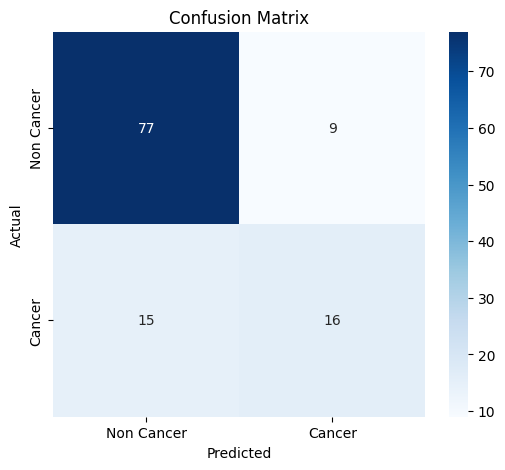

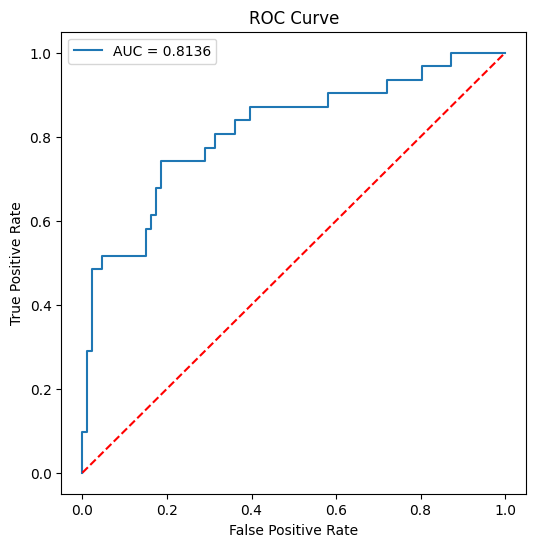

In [28]:
# ============================================================
# CELL 4 : TEST + ROC + CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import seaborn as sns

model.eval()

y_true = []
y_pred = []
y_score = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        outputs = model(images)

        probs = outputs.cpu().numpy()

        preds = (outputs > 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        y_true.extend(labels.cpu().numpy().flatten())
        y_pred.extend(preds.cpu().numpy().flatten())
        y_score.extend(probs.flatten())

test_accuracy = 100 * correct / total

print("Test Accuracy : {:.2f}%".format(test_accuracy))

print("\nClassification Report\n")

print(classification_report(y_true,y_pred))

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non Cancer','Cancer'],
    yticklabels=['Non Cancer','Cancer']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

fpr,tpr,_=roc_curve(y_true,y_score)

roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label="AUC = %.4f"%roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("roc_curve.png")

plt.show()

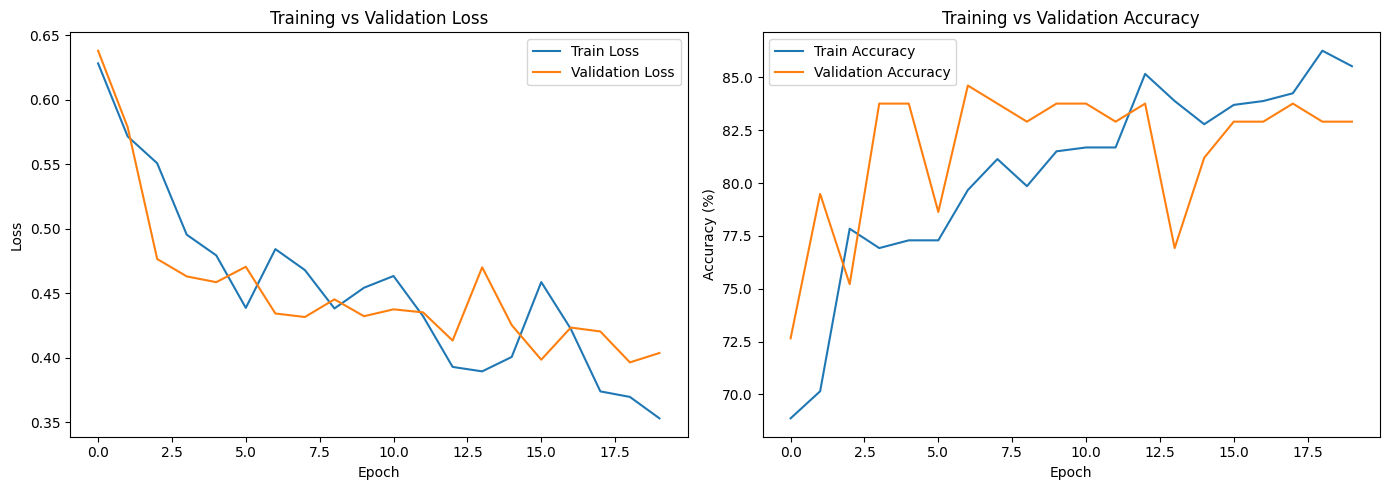

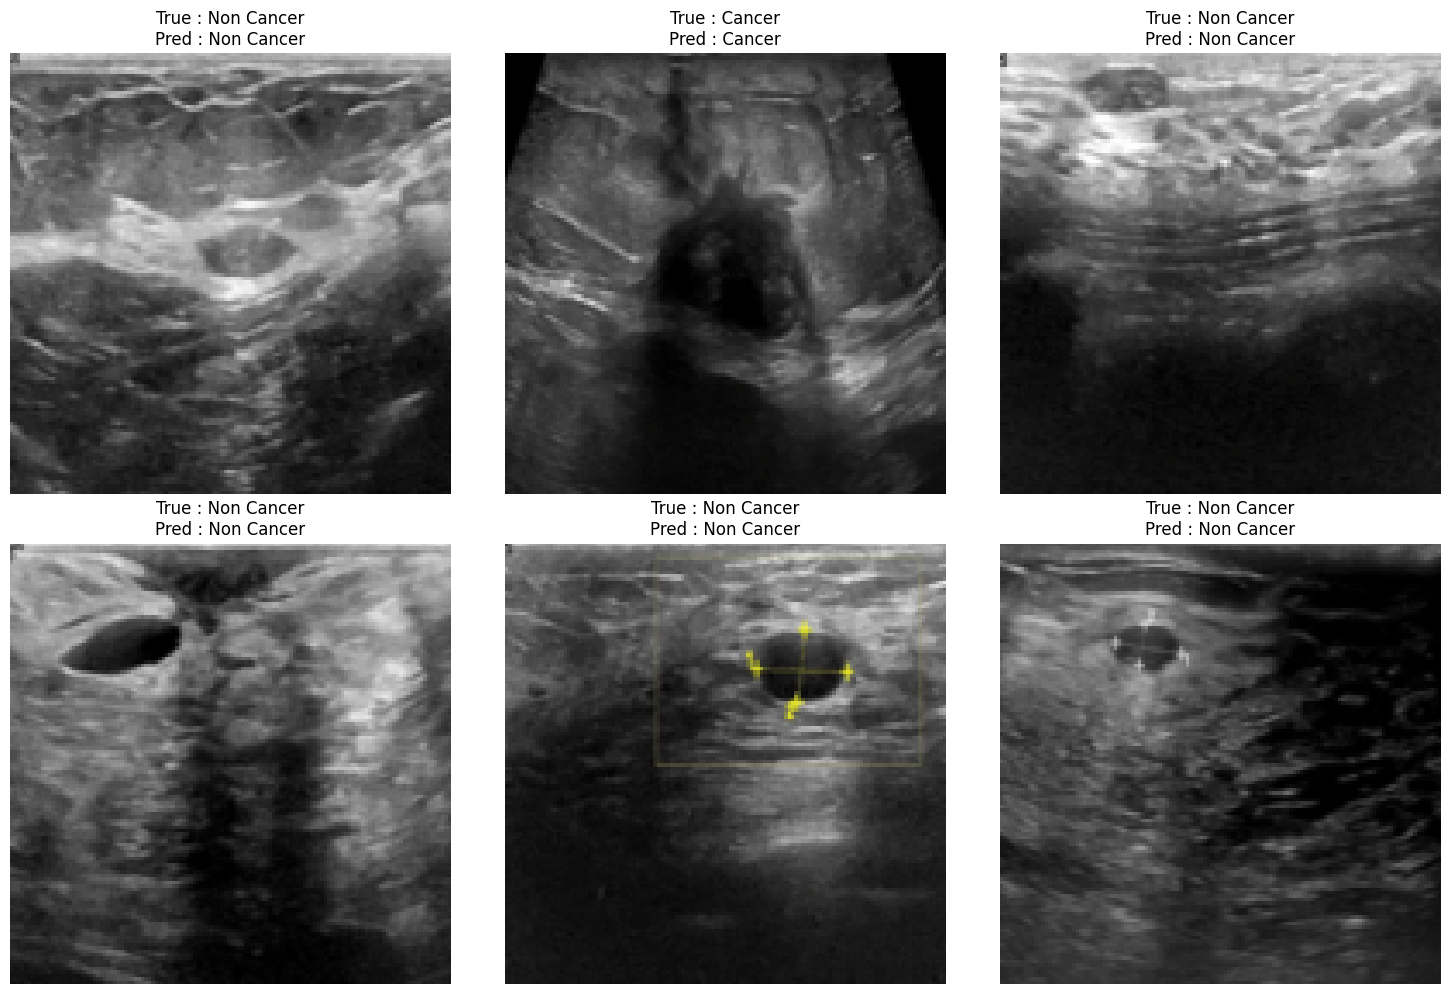

Learning Curve Saved
Sample Prediction Saved


In [29]:
# ============================================================
# CELL 5 : LOSS & ACCURACY CURVES + SAMPLE PREDICTIONS
# ============================================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(train_loss_history,label="Train Loss")
plt.plot(val_loss_history,label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.subplot(1,2,2)

plt.plot(train_acc_history,label="Train Accuracy")
plt.plot(val_acc_history,label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.tight_layout()

plt.savefig("learning_curve.png")

plt.show()


# ----------------------------
# Sample Predictions
# ----------------------------

classes = {
    0:"Non Cancer",
    1:"Cancer"
}

model.eval()

fig=plt.figure(figsize=(15,10))

count=0

with torch.no_grad():

    for images,labels in test_loader:

        images=images.to(device)

        outputs=model(images)

        preds=(outputs>0.5).float()

        for i in range(len(images)):

            if count==6:
                break

            img=images[i].cpu()

            img=img.permute(1,2,0).numpy()

            img=(img*std)+mean

            img=np.clip(img,0,1)

            plt.subplot(2,3,count+1)

            plt.imshow(img)

            plt.title(
                f"True : {classes[int(labels[i])]}\nPred : {classes[int(preds[i])]}"
            )

            plt.axis("off")

            count+=1

        if count==6:
            break

plt.tight_layout()

plt.savefig("sample_predictions.png")

plt.show()

print("Learning Curve Saved")
print("Sample Prediction Saved")

In [33]:
# ============================================================
# CELL 6 : FINAL SAVE + ZIP FILES
# ============================================================

import os
import zipfile
import torch

# Save final model
torch.save(model.state_dict(), "Breast_Cancer_CNN_Model.pth")

print("CNN Model Saved Successfully")


# Create README
readme = """
# Image-Based Cancer Diagnosis Using CNN

Dataset:
BUSI (Breast Ultrasound Images)

Framework:
PyTorch

CNN Architecture:
- 4 Convolution Layers
- Batch Normalization
- MaxPooling
- Dropout
- Fully Connected Layer
- Sigmoid Output

Optimizer:
Adam

Loss Function:
BCELoss

Epochs:
20

Generated Results:
- Learning Curve
- ROC Curve
- Confusion Matrix
- Sample Predictions

Author:
Joyashish Ghosh
"""

with open("README.md","w") as f:
    f.write(readme)


# Create ZIP File
zip_name = "Coding_Assignment_3_Joyashish_Ghosh.zip"

with zipfile.ZipFile(zip_name,"w") as zipf:

    files = [
        "Breast_Cancer_CNN_Model.pth",
        "learning_curve.png",
        "roc_curve.png",
        "confusion_matrix.png",
        "sample_predictions.png",
        "README.md"
    ]

    for file in files:
        if os.path.exists(file):
            zipf.write(file)




CNN Model Saved Successfully


In [34]:
from google.colab import files

files.download("Coding_Assignment_3_Joyashish_Ghosh.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>